In [ ]:
from google.colab import files
uploaded = files.upload()

Saving video_games_sales.csv to video_games_sales (2).csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("video_games_sales.csv")
df.head()

,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
df.shape

(16598, 11)

In [ ]:
df.columns

Index(['rank', 'name', 'platform', 'year', 'genre', 'publisher', 'na_sales',
       'eu_sales', 'jp_sales', 'other_sales', 'global_sales'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          16598 non-null  int64  
 1   name          16598 non-null  object 
 2   platform      16598 non-null  object 
 3   year          16327 non-null  float64
 4   genre         16598 non-null  object 
 5   publisher     16540 non-null  object 
 6   na_sales      16598 non-null  float64
 7   eu_sales      16598 non-null  float64
 8   jp_sales      16598 non-null  float64
 9   other_sales   16598 non-null  float64
 10  global_sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
df.describe()

,rank,year,na_sales,eu_sales,jp_sales,other_sales,global_sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [ ]:
df.isnull().sum()

,0
rank,0
name,0
platform,0
year,271
genre,0
publisher,58
na_sales,0
eu_sales,0
jp_sales,0
other_sales,0


In [ ]:
df['year'] = df['year'].astype('Int64')

In [ ]:
df['hit_game'] = df['global_sales'].apply(lambda x: 'Hit' if x>=10 else 'Flop')

In [ ]:
top_games = df.groupby('name')['global_sales'].sum().sort_values(ascending=False).head(10)
top_games

,global_sales
name,
Wii Sports,82.74
Grand Theft Auto V,55.92
Super Mario Bros.,45.31
Tetris,35.84
Mario Kart Wii,35.82
Wii Sports Resort,33.00
Pokemon Red/Pokemon Blue,31.37
Call of Duty: Black Ops,31.03
Call of Duty: Modern Warfare 3,30.83


In [ ]:
genre_sales = df.groupby('genre')['global_sales'].sum().sort_values(ascending=False)
genre_sales

,global_sales
genre,
Action,1751.18
Sports,1330.93
Shooter,1037.37
Role-Playing,927.37
Platform,831.37
Misc,809.96
Racing,732.04
Fighting,448.91
Simulation,392.20


In [ ]:
platform_sales = df.groupby('platform')['global_sales'].sum().sort_values(ascending=False)
platform_sales

,global_sales
platform,
PS2,1255.64
X360,979.96
PS3,957.84
Wii,926.71
DS,822.49
PS,730.66
GBA,318.50
PSP,296.28
PS4,278.10


In [ ]:
year_sales = df.groupby('year')['global_sales'].sum()
year_sales

,global_sales
year,
1980,11.38
1981,35.77
1982,28.86
1983,16.79
1984,50.36
1985,53.94
1986,37.07
1987,21.74
1988,47.22


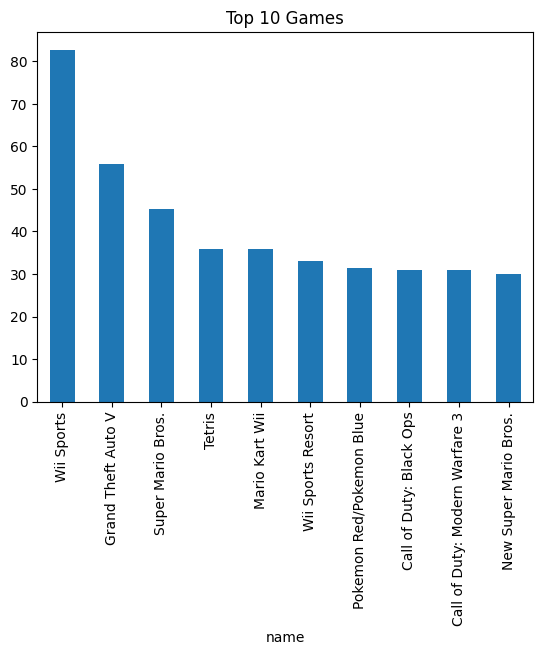

In [ ]:
top_games.plot(kind='bar')
plt.title("Top 10 Games")
plt.show()

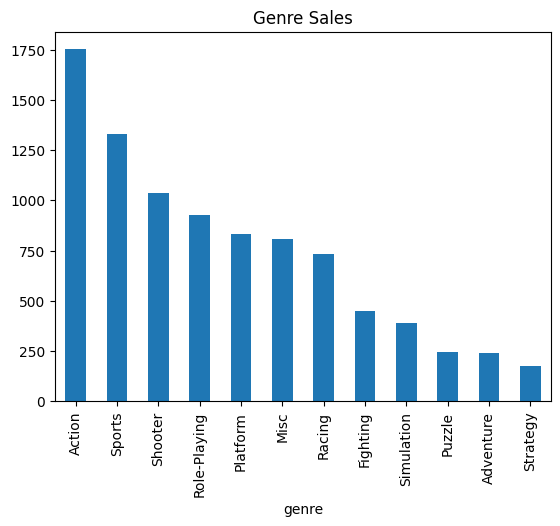

In [ ]:
genre_sales.plot(kind='bar')
plt.title("Genre Sales")
plt.show()

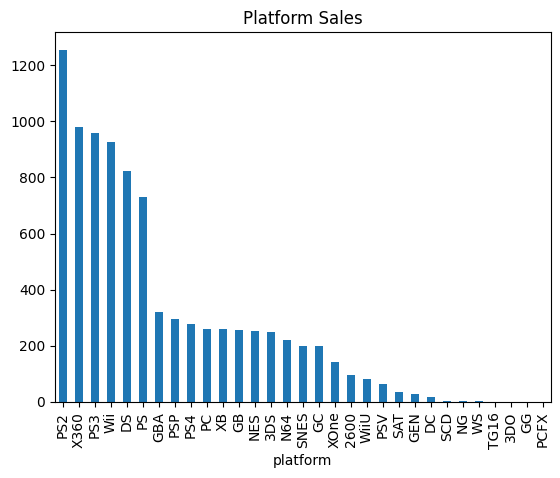

In [ ]:
platform_sales.plot(kind='bar')
plt.title('Platform Sales')
plt.show()

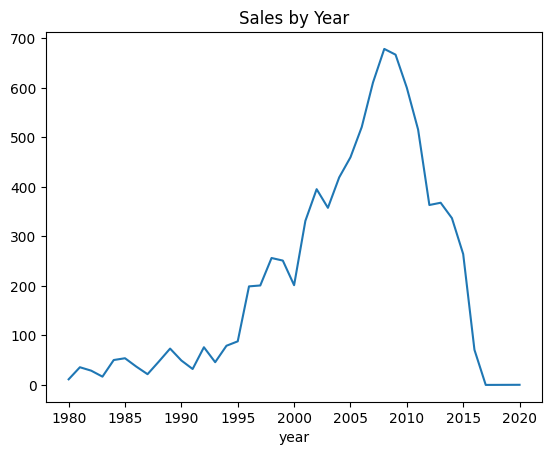

In [ ]:
year_sales.plot()
plt.title('Sales by Year')
plt.show()

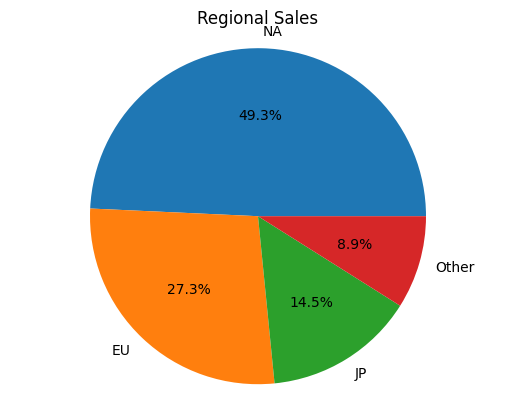

In [ ]:
values = [df['na_sales'].sum(),df['eu_sales'].sum(),df['jp_sales'].sum(),df['other_sales'].sum()]

labels = ['NA', 'EU', 'JP', 'Other']

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Regional Sales")
plt.axis('equal')
plt.show()